In [25]:
import pandas as pd
import numpy as np
import geopandas as gpd
import folium
import gpx_analysis as gpxa
import fiona
import matplotlib.pyplot as plt
import io
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [75]:
paths = ["gpx_data\\alvarado_gravel_wildcat_havey_nimitz_meadow.gpx"]
# paths = [r"gpx_data\three_bears_with_gravel.gpx"]

In [76]:
dfs = []
for path in paths:
    points = gpxa.read_simple_gpx(path, reverse=False)
    df = gpxa.analyze_steps(points, rolling_window=3)
    df['name'] = path.split(".gpx")[0]
    dfs.append(df)
df = pd.concat(dfs, ignore_index=True)

In [92]:
from matplotlib.collections import LineCollection
def basic_elevation_plot(df, color_col=None, default_color="tab:blue", smooth=10):
    y = df["elevation_f"].rolling(smooth, min_periods=1).mean().to_numpy()
    x = np.arange(len(df))

    fig, ax = plt.subplots(figsize=(4, 2))

    if color_col is None:
        ax.plot(x, y, linewidth=3, color=default_color)
    else:
        colors = df[color_col].to_numpy()
        points = np.column_stack([x, y])
        segments = np.stack([points[:-1], points[1:]], axis=1)

        if len(colors) == len(df):
            segment_colors = colors[:-1]
        else:
            segment_colors = colors

        lc = LineCollection(segments, colors=segment_colors, linewidths=3)
        ax.add_collection(lc)
        ax.set_xlim(x.min(), x.max())
        ax.set_ylim(np.nanmin(y), np.nanmax(y))

    ax.plot(
        x,
        np.ones(len(df)) * df["elevation_f"].min(),
        linewidth=4,
        color="grey",
        linestyle=":",
        alpha=0.6,
    )
    ax.set_axis_off()

    # f = io.StringIO()
    # fig.savefig(f, format="svg")
    # svg_data = f.getvalue()
    # plt.close(fig)
    # return svg_data


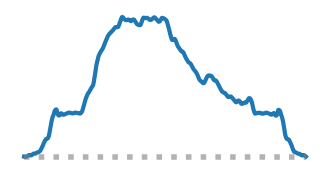

In [93]:
basic_elevation_plot(df)

In [79]:
gpxa.aggregate_by_hazard(df, column='step_dist_f')

,hazard,hazard_label,step_dist_f,percent
0,mellow,Mellow,76087.0,77.0
1,climb,Climb,10491.0,11.0
2,descent,Descent,6722.0,7.0
3,steep_climb,Steep Climb,5108.0,5.0
4,danger_zone,Danger Zone,1015.0,1.0
5,TOTAL,TOTAL,99423.0,100.0


In [114]:
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.lon, df.lat), crs="EPSG:4326").to_crs(26910)
gdf_segments = gpxa.points_to_segments(gdf)

In [115]:
gdf_segments = gdf_segments.set_crs(4326, allow_override=True)

In [116]:
import gpx_analysis.geo as geo


In [117]:
projected_segments = gdf_segments.to_crs(geo.PROJECTED_CRS)
bbox_poly = geo._route_bbox_polygon(projected_segments, 6.0)
print(bbox_poly.bounds)
print(geo._tile_ids_for_bounds(bbox_poly.bounds))
edges = geo._load_local_osm_edges(bbox_poly)
print(len(edges))


(-122.32576389891706, 37.90373747139451, -122.24489610108294, 37.952492500438424)
['x-2447_y758', 'x-2447_y759', 'x-2446_y758', 'x-2446_y759', 'x-2445_y758', 'x-2445_y759']
126371


In [118]:
# gdf_segments = gpxa.points_to_segments(gdf)
# gdf_segments['BART'] = gpxa.geo.add_bart_station(gdf)
# gdf_segments = gpxa.prepare_segment_display_columns(gdf_segments)

In [119]:
gdf_segments = gpxa.enrich_segments_with_osm_edges(
    gdf_segments,
    match_window_size=8,
    match_max_distance_m=1,
    match_preference_tolerance_m=10,
    corridor_m=6.0,
)


In [182]:
gdf_segments['track'] = gdf_segments['osm_highway'].map({'track': 'gravel', 'path': 'gravel'}).fillna('road')

In [193]:
breaks_i

[0, 92, 286, 320, 329, 479, 488, 489, 616, 634, 890, 976]

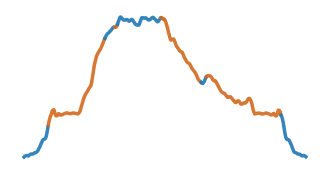

In [226]:
color_map={
        'gravel': "chocolate",
        'road': "tab:blue",
    }
color_col = 'track'
fig, ax = plt.subplots(figsize=(4, 2))
breaks = (gdf_segments['track'] != gdf_segments['track'].shift(-1))
breaks_i = [0] + list(breaks[breaks].index)
gdf_segments['roll_elevation'] = gdf_segments['elevation_f'].rolling(10).mean()
for i in range(len(breaks_i)-1):
    subset = gdf_segments.iloc[breaks_i[i]: breaks_i[i+1], :]
    if len(subset) > 0:
        subset['roll_elevation'].plot(linewidth=2.5,
                    alpha=.9,
                    color=color_map[subset[color_col].iloc[-1]], ax=ax)
    
ax.set_axis_off()

In [214]:
def basic_elevation_plot(
    df,
    color_col=None,
    color_map=None,
    default_color="tab:blue",
    smooth=12,
):
    y = df["elevation_f"].rolling(smooth, min_periods=1).mean().to_numpy()
    x = df['step']

    fig, ax = plt.subplots(figsize=(4, 1))
    color_map = color_map or {}
    
    for i in range(len(df) - 1):
        segment_color = default_color
        if color_col is not None:
            value = df.iloc[i][color_col]
            segment_color = color_map.get(value, default_color)

        ax.plot(
            x[i:i+2],
            y[i:i+2],
            linewidth=2.5,
            alpha=.8,
            color=segment_color,
        )
    else:
        ax.plot(x, y, linewidth=2.5, alpha=.8, color="tab:blue")
    ax.set_axis_off()
    ax.set_axis_off()
    ax.plot(
        x,
        np.ones(len(df)) * df["elevation_f"].min(),
        linewidth=2,
        color="#8d99ae",
        linestyle=":",
        alpha=0.7,
    )
    ax.set_axis_off()


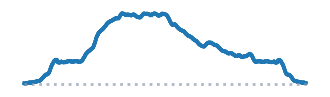

In [215]:
basic_elevation_plot(
    gdf_segments
)


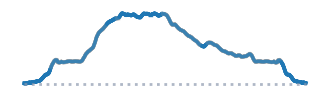

In [216]:
basic_elevation_plot(
    gdf_segments,
    color_col="track",
    color_map={
        'gravel': "darkgrey",
        'road': "tab:blue",
    },
)


In [166]:
gpxa.enrich_segments_with_osm_edges(
    gdf_segments,
    network_type="drive",
    match_window_size=8,
    match_max_distance_m=1,
    match_preference_tolerance_m=10,
    corridor_m=6.0,
).explore(column='osm_highway')

In [67]:
ride_cols = ['Ride Type',
        'Turn',
        'Grade',
        'More Details']
m = gpxa.make_route_map(gdf_segments, popup_cols=ride_cols)
m


In [17]:
import numpy as np

def compute_coast_speed(df, v0=0.0,
                        m_lb=190,        # kg (rider + bike)
                        CdA=0.40,      # m^2
                        Crr=0.005,     # -
                        rho=1.225,     # kg/m^3
                        g=9.81):
    """
    Coasting speed compounded across segments.
    Assumes: downhill segments have NEGATIVE grade (e.g., -0.10 for -10%).
    Requires columns:
      - step_grade (decimal)
      - step_dist_m (meters)
    """
    m = m_lb * 0.45359237 # kg
    grade = df["step_grade"].fillna(0).to_numpy(dtype=float)
    L = df["step_dist_m"].fillna(0).to_numpy(dtype=float)

    speeds = np.empty(len(df), dtype=float)
    v = float(v0)

    k_drag = rho * CdA / m  # constant in the v^2 drag term

    for i in range(len(df)):
        # Convert "negative = downhill" into a positive downhill component
        downhill_component = -grade[i]  # e.g. grade=-0.10 => downhill_component=+0.10

        # Update v^2 using a simple energy/force approximation over distance
        v2 = (
            v**2
            + 2.0 * g * (downhill_component - Crr) * L[i]
            - k_drag * v*v * L[i]
        )

        v = np.sqrt(v2) if v2 > 0 else 0.0
        speeds[i] = v

    df = df.copy()
    df["coast_speed_mps"] = speeds
    df["coast_speed_mph"] = speeds * 2.2369362920544
    return df

In [18]:
# compute_coast_speed(gdf_segments).explore(tooltip="coast_speed_mph", column='coast_speed_mph', style_kwds={"weight": 6}, vmin=0, vmax=40)

In [ ]:
gdf_segments_enriched = gpxa.enrich_segments_with_osm_edges(gdf_segments)
gdf_segments_enriched = gpxa.prepare_osm_columns(gdf_segments_enriched)
stops = gpxa.stop_signs_on_segments(gdf_segments)

In [ ]:
lights = stops[stops["highway"] == "traffic_signals"]
stops  = stops[stops["highway"] == "stop"]

In [ ]:
ride_cols = ['Ride Type',
        'Turn',
        'Grade',
        'More Details']
popup_cols = ['Road Name', 'Road Type', 'Speed Limit']
m = gpxa.make_route_map(gdf_segments_enriched, popup_cols=popup_cols + ride_cols)
gdf.iloc[[gdf['elevation_m'].argmax()]].explore(m=m,  marker_type="marker",
    tooltip=['elevation_f'],
    marker_kwds={
        "icon": folium.Icon(
            color="black",icon="mountain", prefix='fa'
        )
    })
stops.explore(
    m=m,
    tooltip=["highway", "street_count", "More Details"],
    marker_kwds={"radius": 4, "color": "red"},
)
lights.explore(
    m=m,
    tooltip=["highway", "street_count", "More Details"],
    marker_kwds={"radius": 4, "color": "blue", "shape": "square"},
)
m
